# 04: vol

Nobody quotes a volatility per strike. What a desk actually publishes, once per tenor and once
per wing delta, is three numbers: an at-the-money level, a risk reversal and a butterfly.
`fxcarry.vol` undoes that packaging. `Smile` holds the three pieces and turns a wing delta into
a volatility on request, and it refuses a delta it was not given rather than interpolating one,
because filling in a smile between quoted points is a modelling choice this module leaves to
the caller. `VolSurface` is the panel behind it: every quoted option ticker across currencies,
tenors and deltas, decoded into one long frame and sliced into a `Smile` wherever one is asked
for. The next tutorial notebook prices options off exactly what gets built here.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# nbconvert runs with this notebook's folder as the working directory, so walk up
# rather than assume how deep the notebook sits.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "data" / "raw").is_dir())
DATA = ROOT / "data" / "raw"
TAU = 1.0 / 12.0

## Three numbers, unpacked by hand

A `Smile` can be built from nothing but the three quoted numbers, no file involved. `vol` with
no delta returns the at-the-money level; with a delta and a side it returns the call or put
volatility at that wing. Asking for a delta that was never passed in raises `KeyError` rather
than silently returning something close.

The three numbers below sit in the orientation a desk quotes USDJPY in, dollar based, and `Smile`
flips nothing it is handed. So the `call` and `put` labels in this output are the dollar's sides,
not the yen's, and the negative risk reversal is the raw quoted sign. The wing-orientation section
further down is where that gets turned around, and it prints the same currency's risk reversal
with its sign reversed once `VolSurface.smile` has served it as a reading on the yen.

In [2]:
from fxcarry import Smile

hand = Smile(atm=0.0784, risk_reversal={25: -0.0121}, butterfly={25: 0.0026})
print(f"deltas quoted      {hand.deltas}")
print(f"at the money       {hand.vol():.4%}")
print(f"25 delta call      {hand.vol(25, 'call'):.4%}")
print(f"25 delta put       {hand.vol(25, 'put'):.4%}")
print(f"call minus put     {hand.vol(25, 'call') - hand.vol(25, 'put'):+.4%}  "
      "which is the risk reversal")
try:
    hand.vol(10, "call")
except KeyError as err:
    print(f"\nasking for an unquoted wing: {err}")

deltas quoted      (25,)
at the money       7.8400%
25 delta call      7.4950%
25 delta put       8.7050%
call minus put     -1.2100%  which is the risk reversal

asking for an unquoted wing: 'No 10-delta quote on this smile; quoted deltas are (25,).'


## The algebra: call adds, put subtracts

$$\sigma_{\text{call}} = \sigma_{\text{atm}} + \text{bf} + \tfrac{1}{2}\,\text{rr},
\qquad
\sigma_{\text{put}} = \sigma_{\text{atm}} + \text{bf} - \tfrac{1}{2}\,\text{rr}$$

`vol` is exactly these two lines. A call sits above the butterfly by half the risk reversal, a
put sits below it by the same half, so the two are pinned to opposite sides of at-the-money plus
the butterfly. Subtract the two equations and the butterfly cancels, leaving the risk reversal on
its own, which is what the `call minus put` line above recovers to four decimal places:
-1.2100%, the same -0.0121 that was passed in. Average the two equations instead and the risk
reversal is what cancels, leaving the butterfly sitting on top of at-the-money. The risk reversal
carries the smile's asymmetry, the butterfly its curvature, and neither leaks into the other by
construction.

## The surface, read whole before it can be filtered

`VolSurface.from_source` cannot skip rows before it has parsed every ticker in the file, so even
a request for one tenor and two deltas starts by reading `fx_vol_daily.parquet` in full: 16.0
million rows, decoded and only then filtered down. That takes on the order of ten seconds to
half a minute depending on the machine and the disk cache, timed below. The wait is inherent to
how the source works, not a sign that anything has stalled.

In [3]:
import time

import pyarrow.parquet as pq

from fxcarry import Catalog, ParquetSource, VolSurface

catalog = Catalog.default()
raw_rows = pq.ParquetFile(DATA / "fx_vol_daily.parquet").metadata.num_rows

t0 = time.time()
surface = VolSurface.from_source(ParquetSource(DATA / "fx_vol_daily.parquet"), catalog,
                                 tenors=["1M"], deltas=[10, 25])
elapsed = time.time() - t0

print(f"{raw_rows:,} rows in the file, read and decoded, then filtered to 1M, "
      f"10/25 delta in {elapsed:.1f} seconds")
print(surface.frame.shape)
surface.frame.head()

16,040,556 rows in the file, read and decoded, then filtered to 1M, 10/25 delta in 20.2 seconds
(1695144, 7)


,date,iso,kind,delta,tenor,field,value
944220,1996-05-07,CHF,atm,0,1M,mid,9.2
944221,1996-05-07,CHF,atm,0,1M,bid,9.2
944222,1996-05-07,CHF,atm,0,1M,ask,9.7
944223,1996-05-08,CHF,atm,0,1M,mid,8.9
944224,1996-05-08,CHF,atm,0,1M,bid,8.9


## One currency's smile, checked across the whole history

`Smile.vol` and the algebra behind it invert exactly: taking `atm`, `risk_reversal` and
`butterfly` back out of a call and a put has to return what went in. Checking that on one row is
not much of a test, since a single date could hide a bug that only shows up when a currency's
smile goes quiet or the wings cross. The check below runs the identity across JPY's whole
monthly history instead, in one vectorised comparison, and takes the worst residual over every
month rather than the first one that happens to look clean.

In [4]:
jpy = surface.smile("JPY", "1M", freq="M")
rr_resid = (jpy.vol(25, "call") - jpy.vol(25, "put") - jpy.risk_reversal[25]).abs().max()
bf_resid = ((jpy.vol(25, "call") + jpy.vol(25, "put")) / 2 - jpy.atm
            - jpy.butterfly[25]).abs().max()
assert rr_resid < 1e-12 and bf_resid < 1e-12, "the smile does not invert"
print(f"call minus put recovers the risk reversal to {rr_resid:.1e}")
print(f"mean wing less at the money recovers the butterfly to {bf_resid:.1e}")

call minus put recovers the risk reversal to 2.8e-17
mean wing less at the money recovers the butterfly to 1.6e-17


## Which way is up: wing orientation

A quoted risk reversal and butterfly reference the pair's own base currency, not the foreign
one. USDJPY is dollar based, so the quoted call side is a dollar call, which is the same option
as a yen put; the yen call sits on the quoted put side instead. `VolSurface.smile` corrects for
this before handing a smile over: it multiplies the risk reversal by minus one wherever the pair
is not already quoted dollars per foreign unit, so every caller can read `vol(delta, "call")` as
a call on the foreign currency without first checking which side the market happened to quote.
Swapping the two sides is exactly negating the risk reversal, since a call adds half of it and a
put subtracts half; the butterfly is symmetric between the two sides and does not move. The cell
below checks the flip against the raw quote for USDJPY, and checks that AUDUSD, already quoted
dollars per Australian dollar, needs none.

In [5]:
raw = surface.frame
# The brief's version of this filter left out the delta, which lets iloc[-1] land on
# whichever wing (10 or 25) happens to sort last in the raw frame -- here that is the
# 10-delta row, not the 25-delta one jpy.risk_reversal[25] is being checked against.
# Filtering on delta == 25 pins the comparison to the same wing on both sides.
row = raw[(raw.iso == "JPY") & (raw.kind == "rr") & (raw.delta == 25)
          & (raw.field == "mid")].iloc[-1]
print(f"quoted 25 delta risk reversal for USDJPY: {row.value:+.3f} vol points")
print(f"as the library serves it for a yen call:  {jpy.risk_reversal[25].iloc[-1]:+.5f}")
print(f"AUDUSD needs no flip:                     "
      f"{surface.smile('AUD', '1M', freq='M').risk_reversal[25].iloc[-1]:+.5f}")

quoted 25 delta risk reversal for USDJPY: -1.390 vol points


as the library serves it for a yen call:  +0.01390
AUDUSD needs no flip:                     -0.00772


## Across currencies: `panel_smile` and `atm_panel`

`panel_smile` is the same object as `smile`, oriented the same way, but wide enough to hold a
whole cross-section: each of `atm`, `risk_reversal` and `butterfly` becomes a date by currency
frame instead of a single column. A currency that does not quote a given wing contributes a
column of NaN rather than dropping out, so the panel keeps one shape throughout. `atm_panel` is
the narrower, faster version for when only the at-the-money level is needed.

In [6]:
panel = surface.panel_smile("1M", freq="M")
print("atm panel", panel.atm.shape, "deltas", panel.deltas)
atm = surface.atm_panel("1M", freq="M")
atm.iloc[-1].dropna().sort_values(ascending=False).round(4).head(8)

atm panel (392, 19) deltas (10, 25)


HUF    0.1075
KRW    0.1005
ZAR    0.0984
SEK    0.0818
NOK    0.0805
MXN    0.0756
PLN    0.0732
NZD    0.0731
Name: 2026-07-31 00:00:00, dtype: float64

## `term_structure` needs the untrimmed grid

`term_structure` reads the at-the-money quote across every tenor for one currency on one date.
`surface` above was built with `tenors=["1M"]`, so it holds nothing outside that tenor to begin
with: asking it for a term structure does not fail, it just hands back the single tenor it has,
shown below. That is the filter working as built, not a data problem, and the fix is not to
change `term_structure` but to build a second surface without the tenor filter. `from_source`
reads the whole file again regardless of what the catalog asks for, so this second read is
scoped to a single currency's tickers through `catalog.subset(["JPY"])` to keep it cheap.

In [7]:
trap = surface.term_structure("JPY", "2026-06-30")
print("term structure off the 1M-only surface (the trap):")
print(trap)
print()

wide = VolSurface.from_source(
    ParquetSource(DATA / "fx_vol_daily.parquet"), catalog.subset(["JPY"]))
print("term structure off the untrimmed, JPY-only surface:")
wide.term_structure("JPY", "2026-06-30").round(4)

term structure off the 1M-only surface (the trap):


tenor
1M    0.0784
Name: value, dtype: float64



term structure off the untrimmed, JPY-only surface:


tenor
1W     0.0842
1M     0.0784
2M     0.0779
3M     0.0796
6M     0.0826
9M     0.0848
1Y     0.0864
18M    0.0866
2Y     0.0867
Name: value, dtype: float64

## `reindex_like`: coverage narrower than spot

Option volatility is quoted for far fewer currencies than spot is: the panel above covers 19
currencies, not the full spot catalog. A currency with no quote should not price as if its
options were free, and pricing anything at all needs a volatility from somewhere, so the absence
has to show up as NaN and propagate rather than get filled with a convenient stand-in.
`Smile.reindex_like` takes a template's index and columns and reindexes every piece of the smile
onto them, so a currency the template asks for but the smile does not carry comes back NaN in
every field. KWD is the case below: it quotes spot but no option surface, so asking the
reindexed panel for it gives NaN rather than a borrowed number.

In [8]:
template = pd.DataFrame(index=atm.index, columns=["JPY", "AUD", "KWD"], dtype=float)
narrow = panel.reindex_like(template)
print(narrow.atm.iloc[-1].to_dict(), " <- KWD quotes no surface, so it is NaN")

{'JPY': 0.06125, 'AUD': 0.06815, 'KWD': nan}  <- KWD quotes no surface, so it is NaN


## The at-the-money panel through the 2008 crisis

At-the-money volatility is the market's own daily estimate of how much a currency is going to
move, priced forward rather than measured after the fact from realized moves. JPY, AUD and EUR
each reach the highest one-month vol of the whole 2006-2012 window in the same month, printed
below, which lines up with the weeks after Lehman Brothers failed rather than with anything
specific to any one of these three currencies on its own.

JPY peaks at 31.37% on 2008-10
AUD peaks at 40.95% on 2008-10
EUR peaks at 27.27% on 2008-10


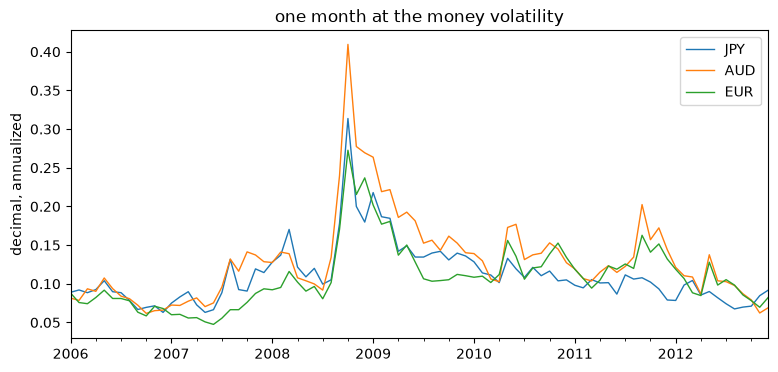

In [9]:
window = atm[["JPY", "AUD", "EUR"]].loc["2006":"2012"]
for ccy in window.columns:
    peak = window[ccy].idxmax()
    print(f"{ccy} peaks at {window[ccy].max():.2%} on {peak:%Y-%m}")

ax = window.plot(figsize=(9, 4), linewidth=1)
ax.set_title("one month at the money volatility")
ax.set_ylabel("decimal, annualized")
plt.show()

## Check yourself

**Why does `Smile` refuse an unquoted delta instead of interpolating?** Turning three quoted
numbers into a volatility at a delta the market never published means assuming a shape for the
smile between the points that are actually quoted, and that assumption is a modelling choice
`Smile` is not in a position to make on a caller's behalf. Raising `KeyError` keeps that choice
visible instead of quietly picking one.

**Why is a yen call the quoted put side?** The risk reversal and butterfly are quoted against
the pair's base currency, and USDJPY's base is the dollar. The quoted call side is therefore a
dollar call, which is the same option as a yen put, so the yen call has to be read off the
quoted put side instead. `VolSurface.smile` flips the risk reversal's sign so a caller never has
to work this out per pair.

**What does `reindex_like` protect against?** A currency that quotes spot but no option surface
getting priced as if a volatility of zero, or some other stand-in, were a fact about the market
rather than a gap in what it published. Reindexing pushes any currency the template asks for but
the smile does not carry to NaN in every field, so the gap propagates through pricing instead of
disappearing.